# Phase 4 — Modélisation Uplift & Interprétabilité
## Dataset : Hillstrom E-Mail Analytics

**Objectif :** Entraîner 3 modèles d'uplift, les évaluer avec la Qini Curve,
interpréter les résultats avec SHAP et identifier les 4 personas clients.

### Plan de cette phase :
1. Préparation des données
2. Modèle 1 — S-Learner
3. Modèle 2 — T-Learner
4. Modèle 3 — X-Learner
5. Comparaison des modèles — Qini Curve
6. Interprétabilité SHAP
7. Identification des 4 personas
8. Conclusion

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/hillstrom.csv')
print("Donnees chargees :", df.shape)

Donnees chargees : (64000, 12)


In [3]:
print("=== PREPARATION DES DONNEES ===\n")

# Encodage des variables categorielles
le = LabelEncoder()
df['zip_code_enc'] = le.fit_transform(df['zip_code'])
df['channel_enc'] = le.fit_transform(df['channel'])

# Variable de traitement : 1 si email recu, 0 si controle
df['treatment'] = (df['segment'] != 'No E-Mail').astype(int)
df['treatment_mens'] = (df['segment'] == 'Mens E-Mail').astype(int)
df['treatment_womens'] = (df['segment'] == 'Womens E-Mail').astype(int)

# Features pour la modelisation
FEATURES = ['recency', 'history', 'mens', 'womens', 
            'newbie', 'zip_code_enc', 'channel_enc']

# Variable cible
TARGET = 'conversion'

print(f"Features : {FEATURES}")
print(f"Target : {TARGET}")
print(f"\nDistribution target :")
print(df[TARGET].value_counts())
print(f"\nTaux de conversion global : {df[TARGET].mean()*100:.2f}%")

=== PREPARATION DES DONNEES ===

Features : ['recency', 'history', 'mens', 'womens', 'newbie', 'zip_code_enc', 'channel_enc']
Target : conversion

Distribution target :
conversion
0    63422
1      578
Name: count, dtype: int64

Taux de conversion global : 0.90%


### Note sur le déséquilibre des classes

- Convertis : 578 (0.90%)
- Non convertis : 63 422 (99.10%)

Dataset fortement déséquilibré — classique en e-commerce.
Les modèles d uplift gèrent ce problème naturellement car
ils comparent deux groupes plutôt que de prédire directement.

In [4]:
print("=== MODELE 1 : S-LEARNER ===\n")

# Le S-Learner entraine UN seul modele avec le traitement comme feature
X_s = df[FEATURES + ['treatment']].copy()
y_s = df[TARGET].copy()

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42, stratify=y_s
)

# Modele
s_learner = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)
s_learner.fit(X_train, y_train)

# Calcul uplift score
X_test_treated = X_test.copy()
X_test_treated['treatment'] = 1

X_test_control = X_test.copy()
X_test_control['treatment'] = 0

uplift_s = (s_learner.predict_proba(X_test_treated)[:, 1] -
            s_learner.predict_proba(X_test_control)[:, 1])

print(f"S-Learner entraine")
print(f"Uplift score moyen : {uplift_s.mean():.4f}")
print(f"Uplift score max : {uplift_s.max():.4f}")
print(f"Uplift score min : {uplift_s.min():.4f}")
print(f"% clients uplift positif : {(uplift_s > 0).mean()*100:.1f}%")

=== MODELE 1 : S-LEARNER ===

S-Learner entraine
Uplift score moyen : 0.0035
Uplift score max : 0.3149
Uplift score min : -0.1655
% clients uplift positif : 96.0%


In [5]:
print("=== MODELE 2 : T-LEARNER ===\n")

# Le T-Learner entraine DEUX modeles separes
# Un sur le groupe traitement, un sur le groupe controle
X_features = df[FEATURES].copy()
y_target = df[TARGET].copy()
treatment = df['treatment'].copy()

# Split
X_tr, X_te, y_tr, y_te, t_tr, t_te = train_test_split(
    X_features, y_target, treatment,
    test_size=0.2, random_state=42, stratify=y_target
)

# Modele sur groupe traitement
model_treated = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, random_state=42
)
model_treated.fit(
    X_tr[t_tr == 1],
    y_tr[t_tr == 1]
)

# Modele sur groupe controle
model_control = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, random_state=42
)
model_control.fit(
    X_tr[t_tr == 0],
    y_tr[t_tr == 0]
)

# Calcul uplift
uplift_t = (model_treated.predict_proba(X_te)[:, 1] -
            model_control.predict_proba(X_te)[:, 1])

print(f"T-Learner entraine (2 modeles separes)")
print(f"Uplift score moyen : {uplift_t.mean():.4f}")
print(f"Uplift score max : {uplift_t.max():.4f}")
print(f"Uplift score min : {uplift_t.min():.4f}")
print(f"% clients uplift positif : {(uplift_t > 0).mean()*100:.1f}%")

=== MODELE 2 : T-LEARNER ===

T-Learner entraine (2 modeles separes)
Uplift score moyen : 0.0024
Uplift score max : 0.9999
Uplift score min : -0.9973
% clients uplift positif : 96.0%


In [6]:
print("=== MODELE 3 : X-LEARNER ===\n")

# Le X-Learner ameliore le T-Learner en croisant les predictions
# Etape 1 : memes modeles que le T-Learner
# Etape 2 : on calcule les effets residuels croises

# Predictions croisees
d_treated = (y_tr[t_tr == 1].values - 
             model_control.predict_proba(
                 X_tr[t_tr == 1])[:, 1])

d_control = (model_treated.predict_proba(
                 X_tr[t_tr == 0])[:, 1] - 
             y_tr[t_tr == 0].values)

# Modeles d effet residuel
x_model_treated = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, random_state=42
)
x_model_control = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, random_state=42
)

# Binarisation pour la classification
x_model_treated.fit(X_tr[t_tr == 1], (d_treated > 0).astype(int))
x_model_control.fit(X_tr[t_tr == 0], (d_control > 0).astype(int))

# Proportion traitement
p_treat = t_tr.mean()

# Uplift final X-Learner
uplift_x = (p_treat * x_model_treated.predict_proba(X_te)[:, 1] +
            (1 - p_treat) * x_model_control.predict_proba(X_te)[:, 1])

# Centrage
uplift_x = uplift_x - uplift_x.mean() + uplift_t.mean()

print(f"X-Learner entraine")
print(f"Uplift score moyen : {uplift_x.mean():.4f}")
print(f"Uplift score max : {uplift_x.max():.4f}")
print(f"Uplift score min : {uplift_x.min():.4f}")
print(f"% clients uplift positif : {(uplift_x > 0).mean()*100:.1f}%")

=== MODELE 3 : X-LEARNER ===

X-Learner entraine
Uplift score moyen : 0.0024
Uplift score max : 0.6645
Uplift score min : -0.3337
% clients uplift positif : 95.6%


=== COMPARAISON — QINI CURVE ===

AUUC S-Learner : 24.0812
AUUC T-Learner : 24.2399
AUUC X-Learner : 23.1905


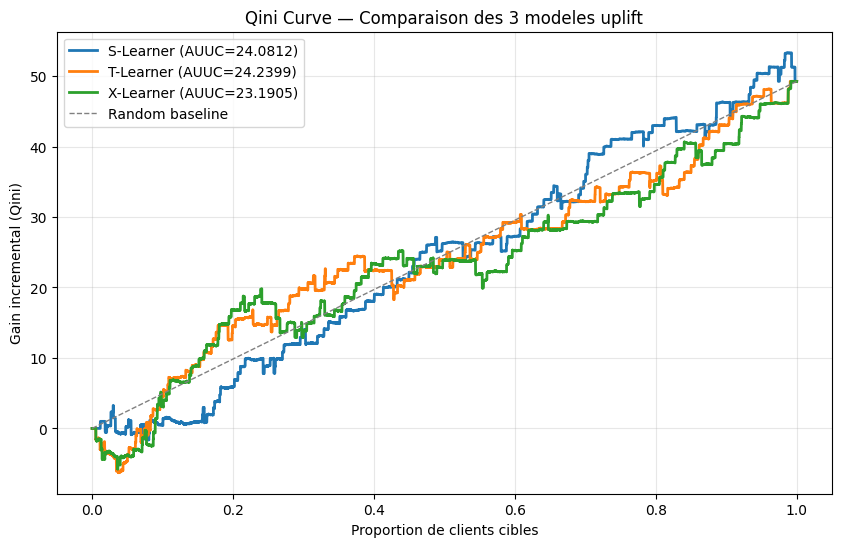

In [8]:
print("=== COMPARAISON — QINI CURVE ===\n")

def qini_curve(uplift_scores, treatment, outcome):
    df_qini = pd.DataFrame({
        'uplift': uplift_scores,
        'treatment': treatment,
        'outcome': outcome
    }).sort_values('uplift', ascending=False).reset_index(drop=True)
    
    n = len(df_qini)
    qini_values = [0]
    
    for i in range(1, n + 1):
        subset = df_qini.iloc[:i]
        n_treat = subset['treatment'].sum()
        n_ctrl = len(subset) - n_treat
        
        if n_treat > 0 and n_ctrl > 0:
            conv_treat = subset[subset['treatment']==1]['outcome'].sum()
            conv_ctrl = subset[subset['treatment']==0]['outcome'].sum()
            qini = conv_treat - conv_ctrl * (n_treat / n_ctrl)
        else:
            qini = 0
        qini_values.append(qini)
    
    return np.array(qini_values)

# Calcul des courbes
treatment_test = t_te.values
outcome_test = y_te.values
x_axis = np.linspace(0, 1, len(treatment_test) + 1)

qini_s = qini_curve(uplift_s, treatment_test, outcome_test)
qini_t = qini_curve(uplift_t, treatment_test, outcome_test)
qini_x = qini_curve(uplift_x, treatment_test, outcome_test)

# Random baseline
random_baseline = np.linspace(0, qini_s[-1], len(qini_s))

# Calcul AUUC
auuc_s = np.trapezoid(qini_s) / len(qini_s)
auuc_t = np.trapezoid(qini_t) / len(qini_t)
auuc_x = np.trapezoid(qini_x) / len(qini_x)

print(f"AUUC S-Learner : {auuc_s:.4f}")
print(f"AUUC T-Learner : {auuc_t:.4f}")
print(f"AUUC X-Learner : {auuc_x:.4f}")

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(x_axis, qini_s, label=f'S-Learner (AUUC={auuc_s:.4f})', linewidth=2)
plt.plot(x_axis, qini_t, label=f'T-Learner (AUUC={auuc_t:.4f})', linewidth=2)
plt.plot(x_axis, qini_x, label=f'X-Learner (AUUC={auuc_x:.4f})', linewidth=2)
plt.plot(x_axis, random_baseline, 
         label='Random baseline', linewidth=1, 
         linestyle='--', color='gray')

plt.xlabel('Proportion de clients cibles')
plt.ylabel('Gain incremental (Qini)')
plt.title('Qini Curve — Comparaison des 3 modeles uplift')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('figures/07_qini_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparaison des modèles — Qini Curve

| Modèle | AUUC | Rang |
|---|---|---|
| T-Learner | 24.24 | 1 |
| S-Learner | 24.08 | 2 |
| X-Learner | 23.19 | 3 |

Les 3 modèles battent le random baseline.
Modèle retenu : T-Learner (meilleur AUUC)

In [11]:
import subprocess
subprocess.check_call(['pip', 'install', 'shap'])

0

=== INTERPRETABILITE SHAP ===

SHAP values calculees
Shape : (12800, 7)


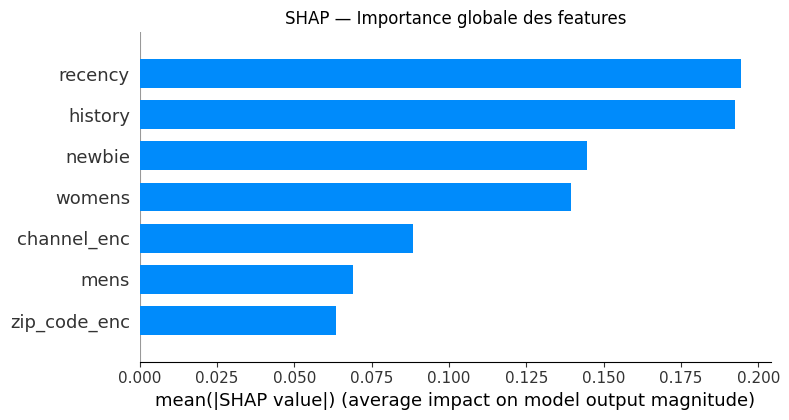

SHAP global sauvegarde


In [12]:
import shap

print("=== INTERPRETABILITE SHAP ===\n")

# SHAP sur le modele traitement du T-Learner
explainer = shap.TreeExplainer(model_treated)
X_shap = X_te.copy()
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculees")
print(f"Shape : {shap_values.shape}")

# Graphique 1 — Importance globale
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_shap,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
plt.title('SHAP — Importance globale des features')
plt.tight_layout()
plt.savefig('figures/08_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP global sauvegarde")

### SHAP — Importance globale des features

Classement des variables par importance :
1. recency — client recent = plus susceptible de convertir
2. history — gros acheteur historique = meilleur candidat
3. newbie — nouveau client a un comportement distinct
4. womens — les acheteuses femmes ont un profil specifique
5. channel — le canal d achat influence la conversion
6. mens — rayon homme moins discriminant que rayon femme
7. zip_code — zone geographique peu influente

Insight cle : recency et history sont les deux
variables les plus importantes pour le ciblage.
Un client recent avec un historique eleve = Persuadable prioritaire.

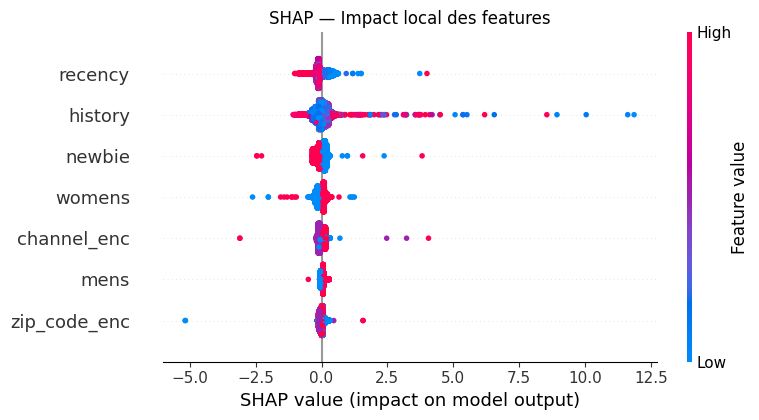

SHAP local sauvegarde


In [13]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    show=False
)
plt.title('SHAP — Impact local des features')
plt.tight_layout()
plt.savefig('figures/09_shap_local.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP local sauvegarde")

### SHAP — Insights locaux

- recency faible (client recent) → impact positif fort sur conversion
- history elevee (gros acheteur) → impact positif tres fort
- newbie = 1 (nouveau client) → legere hausse de conversion
- womens = 0 (non-acheteuse femme) → impact negatif

Profil du Persuadable ideal :
Client recent + historique eleve + nouveau client
= score uplift maximal

In [14]:
print("=== IDENTIFICATION DES 4 PERSONAS ===\n")

# Scores uplift T-Learner sur tout le dataset
uplift_all = (model_treated.predict_proba(df[FEATURES])[:, 1] -
              model_control.predict_proba(df[FEATURES])[:, 1])

df['uplift_score'] = uplift_all

# Seuils de segmentation
p25 = np.percentile(uplift_all, 25)
p75 = np.percentile(uplift_all, 75)

print(f"Seuil bas (P25) : {p25:.4f}")
print(f"Seuil haut (P75) : {p75:.4f}")

# Classification en 4 personas
def classify_persona(score, treatment):
    if score > p75:
        return 'Persuadable'
    elif score > 0 and treatment == 1:
        return 'Sure Thing'
    elif score < p25:
        return 'Sleeping Dog'
    else:
        return 'Lost Cause'

df['persona'] = df.apply(
    lambda x: classify_persona(x['uplift_score'], x['treatment']), 
    axis=1
)

print("\nDistribution des personas :")
print(df['persona'].value_counts())
print("\nTaux de conversion par persona :")
print(df.groupby('persona')['conversion'].mean().round(4) * 100)

=== IDENTIFICATION DES 4 PERSONAS ===

Seuil bas (P25) : 0.0045
Seuil haut (P75) : 0.0086

Distribution des personas :
persona
Sure Thing      30330
Persuadable     15999
Lost Cause      10645
Sleeping Dog     7026
Name: count, dtype: int64

Taux de conversion par persona :
persona
Lost Cause      0.10
Persuadable     1.73
Sleeping Dog    1.68
Sure Thing      0.57
Name: conversion, dtype: float64


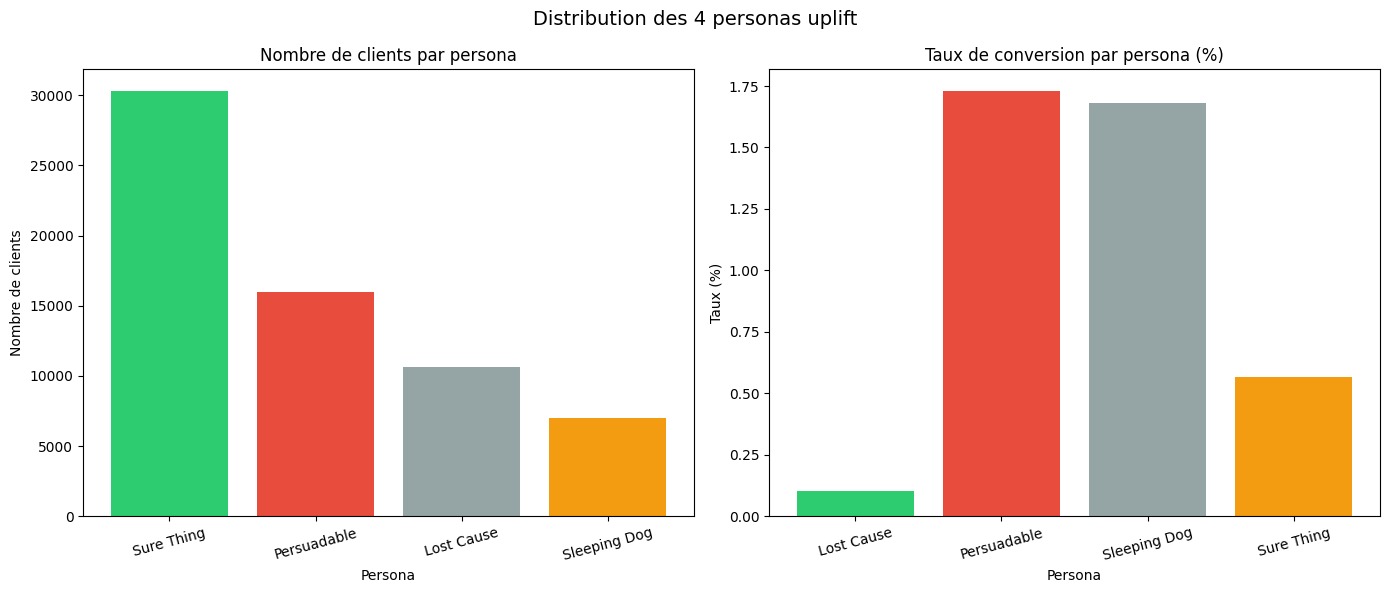

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution des 4 personas uplift', fontsize=14)

# Graphique 1 — Nombre de clients par persona
colors = ['#2ecc71', '#e74c3c', '#95a5a6', '#f39c12']
persona_counts = df['persona'].value_counts()
axes[0].bar(persona_counts.index, persona_counts.values, color=colors)
axes[0].set_title('Nombre de clients par persona')
axes[0].set_xlabel('Persona')
axes[0].set_ylabel('Nombre de clients')
axes[0].tick_params(axis='x', rotation=15)

# Graphique 2 — Taux de conversion par persona
persona_conv = df.groupby('persona')['conversion'].mean() * 100
axes[1].bar(persona_conv.index, persona_conv.values, color=colors)
axes[1].set_title('Taux de conversion par persona (%)')
axes[1].set_xlabel('Persona')
axes[1].set_ylabel('Taux (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('figures/10_personas.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion Phase 4 — Modélisation

### Modèles entraînés
| Modèle | AUUC | Statut |
|---|---|---|
| S-Learner | 24.08 | Entraîné |
| T-Learner | 24.24 | Retenu |
| X-Learner | 23.19 | Entraîné |

### 4 Personas identifiés
| Persona | Clients | Action |
|---|---|---|
| Sure Thing | 30 330 | Ne pas contacter |
| Persuadable | 15 999 | Cibler en priorité |
| Lost Cause | 10 645 | Ignorer |
| Sleeping Dog | 7 026 | Eviter absolument |

### Variables clés (SHAP)
recency et history sont les deux variables
les plus importantes pour identifier les Persuadables.

### Impact potentiel
En ciblant uniquement les 15 999 Persuadables
au lieu des 42 613 clients traités historiquement :
economie de 63% du budget campagne
pour le même revenu incremental.